<a id="content"><h3>Content</h3></a>

[Dependencies, paths and datasets upload](#upload)\
[Mouse clustering](#preprocess_mouse)\
[Human clustering](#preprocess_human)\
[Best silhouette score calculation and plotting for mouse](#silhouette_mouse)\
[Best silhouette score calculation and plotting for human](#silhouette_human)\
[Applying best n_clusters for human and mouse and labeling the terms](#best_silhouette)\
[Distance between each low-level terms pair distribution](#distances)\
[Cluster analysis: mean distance within each cluster calculation](#cluster_distance)\
[Distance within clusters computation](#distances_within)\
[Visualization](#visualization)\
[Associated with different system terms clusters analysis](#syst_clust)\
[Upset plotting ✨✨✨](#upset)\
[Children of each system term frequency in the dataset](#children_freq)


<a id="upload"><h4>Dependencies, paths and datasets upload</h4></a>
[Back to content](#content)

In [2]:
#!/usr/bin/env python3

import os
import itertools
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import upsetplot

from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from low2system import term_to_label

ModuleNotFoundError: No module named 'low2system'

In [2]:
# Create directories for plots and intermediate data
PLOTS_DIR = "../pictures"
INTERMEDIATE_DATA_DIR = "../intermediate_data"
PATH_HPO = os.path.abspath("./ontologies/hpo.json")
PATH_MPO = os.path.abspath("./ontologies/mpo.json")
DATA = "./"

# function for further work with dataset
def isnan(x):
    return x != x

In [3]:
# dataset upload

data = pd.read_csv(
    "./human_mouse_GPO_mono.tsv",
    delimiter="\t"
)

data.head()

,gene_human,entrez_id_human,gene_mouse,MGI,MP_HMD,MP_PhenoGeno,HP_genes_to_phenotype,MP_system_level,HP_system_level,MP_from_HP_system_level,MPO_lower,HPO_lower
0,A1BG,1,A1bg,MGI:2152878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A1CF,29974,A1cf,MGI:1917115,"MP:0005386,MP:0005370,MP:0005378,MP:0005369,MP...","MP:0005378,MP:0003140,MP:0004565,MP:0011925,MP...",NaN,"MP:0005387,MP:0005386,MP:0005378,MP:0005369,MP...",NaN,NaN,"MP:0005378,MP:0003140,MP:0004565,MP:0011925,MP...",NaN
2,A2M,2,A2m,MGI:2449119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A3GALT2,127550,A3galt2,MGI:2685279,NaN,MP:0002169,NaN,NaN,NaN,NaN,NaN,NaN
4,A4GALT,53947,A4galt,MGI:3512453,"MP:0005386,MP:0005376,MP:0010768","MP:0009747,MP:0009767,MP:0008874",NaN,"MP:0005386,MP:0005376,MP:0010768",NaN,NaN,"MP:0009747,MP:0009767,MP:0008874",NaN


<a id="preprocess_mouse"><h4>Mouse clustering</h4></a>
[Back to content](#content)

In [5]:
# All low-level MPs list

mp_exists = data[
    data.MPO_lower\
        .apply(lambda x: not isnan(x))
]

mps_low_raw = mp_exists.MPO_lower\
    .apply(lambda x: x.split(","))\
    .tolist()

mps_low = list(set(list(itertools.chain(*mps_low_raw))))

In [11]:
# Dict MP low-level term: gene list creation

mouse_gene_pheno = [
    mp_exists.gene_human.tolist(),
    mp_exists.MPO_lower.tolist()
]

mouse_mps_dict = defaultdict(list)

for idx in range(len(mouse_gene_pheno[0])):
    gene = mouse_gene_pheno[0][idx]
    mps = mouse_gene_pheno[1][idx]

    for mp in mps.split(","):
        mouse_mps_dict[mp].append(gene)

In [7]:
# Jaccard indexes for each low-level MP pair count

jcrd_m_m = [[]]

for mp_1 in mps_low:
    jcrd_line = []
    for mp_2 in mps_low:
        jcrd_val = len(
            set(mouse_mps_dict[mp_1]).intersection(set(mouse_mps_dict[mp_2]))
        ) / len(set(mouse_mps_dict[mp_1]).union(set(mouse_mps_dict[mp_2])))
        jcrd_line.append(jcrd_val)
    jcrd_m_m.extend([jcrd_line])

jcrd_mouse_mouse = pd.DataFrame(
    jcrd_m_m[1:], 
    columns=mps_low, 
    index=mps_low
)

In [16]:
# Sinkevich indexes for each low-level MP pair count

snk_m_m = [[]]

for mp_1 in mps_low:
    snk_line = []
    for mp_2 in mps_low:
        snk_val = len(
            set(mouse_mps_dict[mp_1]).intersection(set(mouse_mps_dict[mp_2]))
        ) / min(len(set(mouse_mps_dict[mp_1])), len(set(mouse_mps_dict[mp_2])))
        snk_line.append(snk_val)
    snk_m_m.extend([snk_line])

snk_mouse_mouse = pd.DataFrame(
    snk_m_m[1:], 
    columns=mps_low, 
    index=mps_low
)

In [8]:
# convert Jaccard indexes to distances and save to csv

jcrd_distances_mouse = 1 - jcrd_mouse_mouse

jcrd_distances_mouse.to_csv(
    "../intermediate_data/clustering_mouse_low_jcrd.csv"
)

In [17]:
# convert Sinkevich indexes to distances and save to csv

snk_distances_mouse = 1 - snk_mouse_mouse

snk_distances_mouse.to_csv(
    "../intermediate_data/clustering_mouse_low_snk.csv"
)

<a id="preprocess_human"><h4>Human clustering</h4></a>
[Back to content](#content)

In [18]:
# All low-level HPs listMP:0011758

hp_exists = data[
    data.HPO_lower\
        .apply(lambda x: not isnan(x))
]

hps_low_raw = hp_exists.HPO_lower\
    .apply(lambda x: x.split(","))\
    .tolist()

hps_low = list(set(list(itertools.chain(*hps_low_raw))))

In [19]:
# Dict HP low-level term: gene list creation

human_gene_pheno = [
    hp_exists.gene_human.tolist(),
    hp_exists.HPO_lower.tolist()
]

human_hps_dict = defaultdict(list)

for idx in range(len(human_gene_pheno[0])):
    gene = human_gene_pheno[0][idx]
    hps = human_gene_pheno[1][idx]

    for hp in hps.split(","):
        human_hps_dict[hp].append(gene)

In [11]:
# Jaccard indexes for each low-level HP pair count

jcrd_h_h = [[]]

for hp_1 in hps_low:
    jcrd_line = []
    for hp_2 in hps_low:
        jcrd_val = len(
            set(human_hps_dict[hp_1]).intersection(set(human_hps_dict[hp_2]))
        ) / len(set(human_hps_dict[hp_1]).union(set(human_hps_dict[hp_2])))
        jcrd_line.append(jcrd_val)
    jcrd_h_h.extend([jcrd_line])

jcrd_human_human = pd.DataFrame(
    jcrd_h_h[1:], 
    columns=hps_low, 
    index=hps_low
)

In [20]:
# Sinkevich indexes for each low-level HP pair count

snk_h_h = [[]]

for hp_1 in hps_low:
    snk_line = []
    for hp_2 in hps_low:
        snk_val = len(
            set(human_hps_dict[hp_1]).intersection(set(human_hps_dict[hp_2]))
        ) / min(len(set(human_hps_dict[hp_1])), len(set(human_hps_dict[hp_2])))
        snk_line.append(snk_val)
    snk_h_h.extend([snk_line])

snk_human_human = pd.DataFrame(
    snk_h_h[1:], 
    columns=hps_low, 
    index=hps_low
)

In [12]:
# convert Jaccard indexes to distances and save to csv

jcrd_distances_human = 1 - jcrd_human_human

jcrd_distances_human.to_csv(
    "../intermediate_data/clustering_human_low_jcrd.csv"
)

In [21]:
# convert Sinkevich indexes to distances and save to csv

snk_distances_human = 1 - snk_human_human

snk_distances_human.to_csv(
    "../intermediate_data/clustering_human_low_snk.csv"
)

<a id="silhouette_mouse"><h4>Best silhouette score calculation for mouse</h4></a>
[Back to content](#content)

In [3]:
mouse_distances = pd.read_csv(
    "../intermediate_data/clustering_mouse_low_snk.csv",
    index_col=0
)

In [5]:
mouse_distances.head()

,MP:0005136,MP:0011530,MP:0011758,MP:0031421,MP:0004956,MP:0004376,MP:0008027,MP:0005481,MP:0006167,MP:0030472,...,MP:0011160,MP:0010454,MP:0010877,MP:0003434,MP:0011685,MP:0003151,MP:0030280,MP:0009228,MP:0006322,MP:0012146
MP:0005136,0.00,1.0,1.0,1.0,0.96,1.000000,1.0,1.000000,1.0,1.0,...,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0
MP:0011530,1.00,0.0,1.0,1.0,1.00,1.000000,1.0,1.000000,1.0,1.0,...,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0
MP:0011758,1.00,1.0,0.0,1.0,1.00,1.000000,1.0,1.000000,1.0,1.0,...,1.000000,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0
MP:0031421,1.00,1.0,1.0,0.0,1.00,1.000000,1.0,1.000000,1.0,1.0,...,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0
MP:0004956,0.96,1.0,1.0,1.0,0.00,0.933333,1.0,0.916667,1.0,1.0,...,0.916667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.833333,1.0


In [9]:
# Find the optimal number of clusters

mouse_sil = []

best_n_clusters = 2
best_silhouette_score = -1

for n_clusters in range(2, mouse_distances.shape[0], 50):
    clustering = AgglomerativeClustering(n_clusters=n_clusters, 
                                         metric='precomputed', 
                                         linkage='complete')
    cluster_labels = clustering.fit_predict(mouse_distances)

    silhouette_avg = silhouette_score(mouse_distances, 
                                      cluster_labels, 
                                      metric='precomputed')
    
    mouse_sil.append([n_clusters, silhouette_avg])

    # print(f"For {n_clusters} clusters, the average silhouette score is {silhouette_avg}")

    if silhouette_avg > best_silhouette_score:
        best_silhouette_score = silhouette_avg
        best_n_clusters = n_clusters

print(f"The optimal number of clusters is {best_n_clusters}")
print(f"The silhouette score is {best_silhouette_score}")

The optimal number of clusters is 7152
The silhouette score is 0.27554070054773117


In [10]:
# silhouette score clarification

for n_clusters in range(7100, 7200):
    clustering = AgglomerativeClustering(n_clusters=n_clusters, 
                                         metric='precomputed', 
                                         linkage='complete')
    cluster_labels = clustering.fit_predict(mouse_distances)

    silhouette_avg = silhouette_score(mouse_distances, 
                                      cluster_labels, 
                                      metric='precomputed')
    
    mouse_sil.append([n_clusters, silhouette_avg])

    # print(f"For {n_clusters} clusters, the average silhouette score is {silhouette_avg}")

    if silhouette_avg > best_silhouette_score:
        best_silhouette_score = silhouette_avg
        best_n_clusters = n_clusters

print(f"The optimal number of clusters is {best_n_clusters}")
print(f"The silhouette score is {best_silhouette_score}")

The optimal number of clusters is 7138
The silhouette score is 0.2761586475825732


In [15]:
np.min(np.array(mouse_sil)[:, 1])

-0.1512165318281462

''

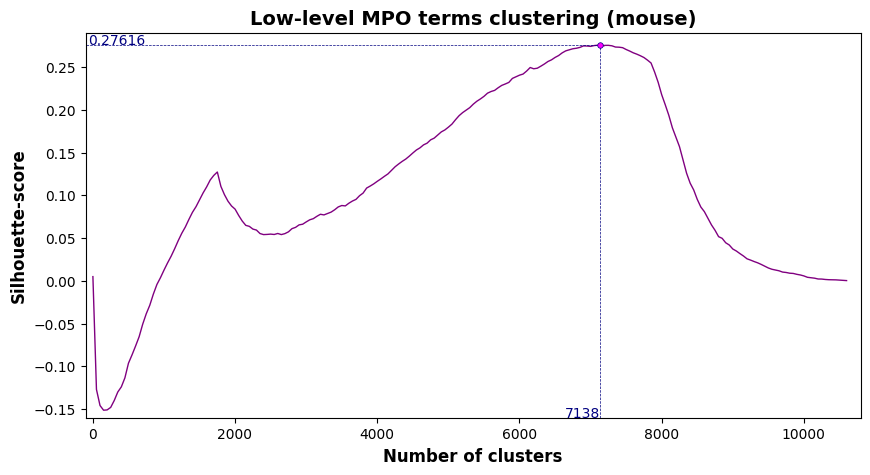

In [18]:
plt.figure(figsize=(10, 5))

clusters = np.array(mouse_sil)[:, 0]
silhouettes = np.array(mouse_sil)[:, 1]
sns.lineplot(
    x=clusters, 
    y=silhouettes,
    linewidth=1,
    color="purple"
)

ymin, ymax = -0.16, 0.29
plt.ylim(ymin, ymax)
xmin, xmax = -100, 10800
plt.xlim(xmin, xmax)

ymaxline = (best_silhouette_score - np.min(silhouettes)) / (ymax - np.min(silhouettes))
xmaxline = (best_n_clusters - np.min(clusters)) / (xmax - np.min(clusters))

lineset = {
    "linestyle": "--",
    "linewidth": 0.5,
    "color": "navy"
}

plt.axvline(
    x=best_n_clusters,
    ymax=ymaxline,
    **lineset
)
plt.axhline(
    y=best_silhouette_score,
    xmax=xmaxline,
    **lineset
)

plt.plot(
    best_n_clusters, 
    best_silhouette_score,
    color="magenta",
    marker="o",
    markersize=4,
    markeredgecolor="navy", 
    markeredgewidth=0.5
)

plt.annotate(
    text=best_n_clusters,
    xy=(best_n_clusters, ymin + 0.0005),
    ha="right",
    color="navy"
)
plt.annotate(
    text=f"{best_silhouette_score:.5f}",
    xy=(xmin + 30, best_silhouette_score + 0.0005),
    color="navy"
)

plt.xlabel(
    "Number of clusters",
    size=12,
    weight="semibold"
)
plt.ylabel(
    "Silhouette-score",
    size=12,
    weight="semibold"
)
plt.title(
    "Low-level MPO terms clustering (mouse)",
    size=14,
    weight="bold"
)

plt.savefig(
    f"{PLOTS_DIR}/best_n_clusters_mouse.png",
    bbox_inches="tight",
    dpi=800
)
("")

<a id="silhouette_human"><h4>Best silhouette score calculation and plotting for human</h4></a>
[Back to content](#content)

In [4]:
human_distances = pd.read_csv(
    "../intermediate_data/clustering_human_low_snk.csv",
    index_col=0
)

human_distances.head()

,HP:0001039,HP:0025336,HP:0002761,HP:0008798,HP:0011649,HP:0034633,HP:0000826,HP:0002209,HP:0011560,HP:0000710,...,HP:0007260,HP:0007373,HP:0031187,HP:0200008,HP:0004357,HP:0034010,HP:0001832,HP:0012091,HP:0100628,HP:0030320
HP:0001039,0.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000,1.0,1.0,1.000,1.0,1.0,1.000,1.0,1.0,1.000000
HP:0025336,1.0,0.0,1.0,1.0,1.0,1.0,0.941176,1.000000,1.000000,0.933333,...,0.875,1.0,1.0,0.975,1.0,1.0,1.000,1.0,1.0,0.833333
HP:0002761,1.0,1.0,0.0,1.0,1.0,1.0,0.957447,0.978723,0.916667,1.000000,...,1.000,1.0,1.0,1.000,1.0,1.0,0.875,1.0,1.0,1.000000
HP:0008798,1.0,1.0,1.0,0.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000,1.0,1.0,1.000,1.0,1.0,1.000,1.0,1.0,1.000000
HP:0011649,1.0,1.0,1.0,1.0,0.0,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000,1.0,1.0,1.000,1.0,1.0,1.000,1.0,1.0,1.000000


In [21]:
# Find the optimal number of clusters

human_sil = []

best_n_clusters_2 = 2
best_silhouette_score_2 = -1

for n_clusters in range(2, human_distances.shape[0], 50):
    clustering = AgglomerativeClustering(n_clusters=n_clusters, 
                                         metric='precomputed', 
                                         linkage='complete')
    cluster_labels = clustering.fit_predict(human_distances)

    silhouette_avg = silhouette_score(human_distances, 
                                      cluster_labels, 
                                      metric='precomputed')
    
    human_sil.append([n_clusters, silhouette_avg])

    # print(f"For {n_clusters} clusters, the average silhouette score is {silhouette_avg}")

    if silhouette_avg > best_silhouette_score_2:
        best_silhouette_score_2 = silhouette_avg
        best_n_clusters_2 = n_clusters

print(f"The optimal number of clusters is {best_n_clusters_2}")
print(f"The silhouette score is {best_silhouette_score_2}")

The optimal number of clusters is 5552
The silhouette score is 0.34368499792493307


In [22]:
# silhouette score clarification

for n_clusters in range(5500, 5600):
    clustering = AgglomerativeClustering(n_clusters=n_clusters, 
                                         metric='precomputed', 
                                         linkage='complete')
    cluster_labels = clustering.fit_predict(human_distances)

    silhouette_avg = silhouette_score(human_distances, 
                                      cluster_labels, 
                                      metric='precomputed')
    
    human_sil.append([n_clusters, silhouette_avg])

    # print(f"For {n_clusters} clusters, the average silhouette score is {silhouette_avg}")

    if silhouette_avg > best_silhouette_score_2:
        best_silhouette_score_2 = silhouette_avg
        best_n_clusters_2 = n_clusters

print(f"The optimal number of clusters is {best_n_clusters_2}")
print(f"The silhouette score is {best_silhouette_score_2}")

The optimal number of clusters is 5540
The silhouette score is 0.34396407447230987


In [26]:
np.min(np.array(human_sil)[:, 1]), np.max(np.array(human_sil)[:, 1])

(-0.18432970524249218, 0.34396407447230987)

''

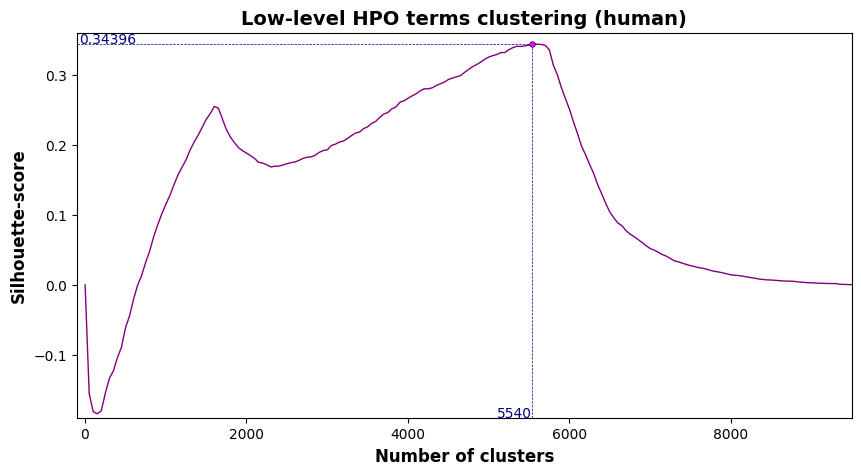

In [29]:
plt.figure(figsize=(10, 5))

clusters = np.array(human_sil)[:, 0]
silhouettes = np.array(human_sil)[:, 1]
sns.lineplot(
    x=clusters, 
    y=silhouettes,
    linewidth=1,
    color="purple"
)

ymin, ymax = -0.19, 0.36
plt.ylim(ymin, ymax)
xmin, xmax = -100, 9500
plt.xlim(xmin, xmax)

ymaxline = (best_silhouette_score_2 - np.min(silhouettes)) / (ymax - np.min(silhouettes))
xmaxline = (best_n_clusters_2 - np.min(clusters)) / (xmax - np.min(clusters))

lineset = {
    "linestyle": "--",
    "linewidth": 0.5,
    "color": "navy"
}

plt.axvline(
    x=best_n_clusters_2,
    ymax=ymaxline,
    **lineset
)
plt.axhline(
    y=best_silhouette_score_2,
    xmax=xmaxline,
    **lineset
)

plt.plot(
    best_n_clusters_2, 
    best_silhouette_score_2,
    color="magenta",
    marker="o",
    markersize=4,
    markeredgecolor="navy", 
    markeredgewidth=0.5
)

plt.annotate(
    text=best_n_clusters_2,
    xy=(best_n_clusters_2, ymin + 0.001),
    ha="right",
    color="navy"
)
plt.annotate(
    text=f"{best_silhouette_score_2:.5f}",
    xy=(xmin + 30, best_silhouette_score_2 + 0.001),
    color="navy"
)

plt.xlabel(
    "Number of clusters",
    size=12,
    weight="semibold"
)
plt.ylabel(
    "Silhouette-score",
    size=12,
    weight="semibold"
)
plt.title(
    "Low-level HPO terms clustering (human)",
    size=14,
    weight="bold"
)

plt.savefig(
    f"{PLOTS_DIR}/best_n_clusters_human.png",
    bbox_inches="tight",
    dpi=800
)
("")

<a id="best_silhouette"><h4>Applying best n_clusters for human and mouse and labeling the terms</h4></a>
[Back to content](#content)

In [7]:
sns.clustermap(mouse_distances)

/home/nadia/BI/genotype_to_phenotype/environment/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nadia/BI/genotype_to_phenotype/environment/lib/python3.9/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/nadia/BI/genotype_to_phenotype/environment/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nadia/BI/genotype_to_phenotype/environment/lib/python3.9/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = 

In [5]:
best_n_clusters_m, best_n_clusters_h = 7138, 5540

In [6]:
clustering_m = AgglomerativeClustering(n_clusters=best_n_clusters_m, 
                                         metric='precomputed', 
                                         linkage='complete')
cluster_labels_m = clustering_m.fit_predict(mouse_distances)

In [8]:
# make the DF of MPO term matching cluster label

term_to_cluster_m = pd.DataFrame(mouse_distances.columns.tolist(), cluster_labels_m)\
    .reset_index()\
    .rename(columns={"index": "cluster_label", 0: "MPO_term"})\
    .reindex(columns=["MPO_term", "cluster_label"])

term_to_cluster_m["MPO_label"] = term_to_cluster_m.MPO_term.apply(lambda x: term_to_label(x))

term_to_cluster_m.to_csv(f"{INTERMEDIATE_DATA_DIR}/term_to_cluster_mouse.tsv", sep="\t", index=False)

In [10]:
clustering_h = AgglomerativeClustering(n_clusters=best_n_clusters_h, 
                                         metric='precomputed', 
                                         linkage='complete')
cluster_labels_h = clustering_h.fit_predict(human_distances)

dissimilarities_h = np.max(human_distances) - human_distances

mds_h = MDS(n_components=2, dissimilarity='precomputed')
coordinates_h = mds_h.fit_transform(dissimilarities_h)

In [11]:
# make the DF of HPO term matching cluster label

term_to_cluster_h = pd.DataFrame(human_distances.columns.tolist(), cluster_labels_h)\
    .reset_index()\
    .rename(columns={"index": "cluster_label", 0: "HPO_term"})\
    .reindex(columns=["HPO_term", "cluster_label"])

term_to_cluster_h["HPO_label"] = term_to_cluster_h.HPO_term.apply(lambda x: term_to_label(x))

term_to_cluster_h.to_csv(f"{INTERMEDIATE_DATA_DIR}/term_to_cluster_human.tsv", sep="\t", index=False)

In [12]:
gpo = data[['gene_human', 'entrez_id_human', 'gene_mouse', 'MGI', 'MPO_lower', 'HPO_lower']]

In [30]:
gpo["clusters_m"] = gpo.MPO_lower.apply(lambda x: ",".join(list(map(lambda f: str(term_to_cluster_m.loc[term_to_cluster_m.MPO_term == f].cluster_label.astype(int).values[0]), x.split(",")))) if not isnan(x) else x)

/tmp/ipykernel_6134/3374631927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpo["clusters_m"] = gpo.MPO_lower.apply(lambda x: ",".join(list(map(lambda f: str(term_to_cluster_m.loc[term_to_cluster_m.MPO_term == f].cluster_label.astype(int).values[0]), x.split(",")))) if not isnan(x) else x)


In [35]:
gpo["clusters_h"] = gpo.HPO_lower.apply(lambda x: ",".join(list(map(lambda f: str(term_to_cluster_h.loc[term_to_cluster_h.HPO_term == f].cluster_label.astype(int).values[0]), x.split(",")))) if not isnan(x) else x)

/tmp/ipykernel_6134/2911281995.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpo["clusters_h"] = gpo.HPO_lower.apply(lambda x: ",".join(list(map(lambda f: str(term_to_cluster_h.loc[term_to_cluster_h.HPO_term == f].cluster_label.astype(int).values[0]), x.split(",")))) if not isnan(x) else x)


In [59]:
gpo["n_clusters_m"] = gpo.clusters_m.apply(lambda x: int(len(set(x.split(",")))) if not isnan(x) else x).astype("Int64")
gpo["n_clusters_h"] = gpo.clusters_h.apply(lambda x: int(len(set(x.split(",")))) if not isnan(x) else x).astype("Int64")

/tmp/ipykernel_6134/3786473157.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpo["n_clusters_m"] = gpo.clusters_m.apply(lambda x: int(len(set(x.split(",")))) if not isnan(x) else x).astype("Int64")
/tmp/ipykernel_6134/3786473157.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpo["n_clusters_h"] = gpo.clusters_h.apply(lambda x: int(len(set(x.split(",")))) if not isnan(x) else x).astype("Int64")


In [61]:
gpo.to_csv(f"{INTERMEDIATE_DATA_DIR}/human_mouse_gene_to_cluster.tsv", sep="\t")